In [17]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import os
import pickle

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from adaptive_smc.save_and_read_and_postprocess import acf2, correct_acf, acf


PKLs = []
PKL_titles = []
DIR = "./output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        PKLs.append(pickle.load(open(DIR + file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [25]:
idx_proposal = dict()
for i in range(n):
    proposal = PKLs[i]['config']['proposal']
    idx_proposal[proposal] = idx_proposal.get(proposal, []) + ([i])

mapping_labels = {'build_build_autoregressive_gaussian_proposal' : 'pCN',
'build_gaussian_rwmh_cov_proposal_gamma' : 'aRW',
'build_build_uncoupled_autoregressive_gaussian_proposal' : r"ARW"}

idx_proposal = {mapping_labels[proposal]: idx_proposal[proposal] for proposal in idx_proposal}

In [28]:
PKLs_titles[1]

3

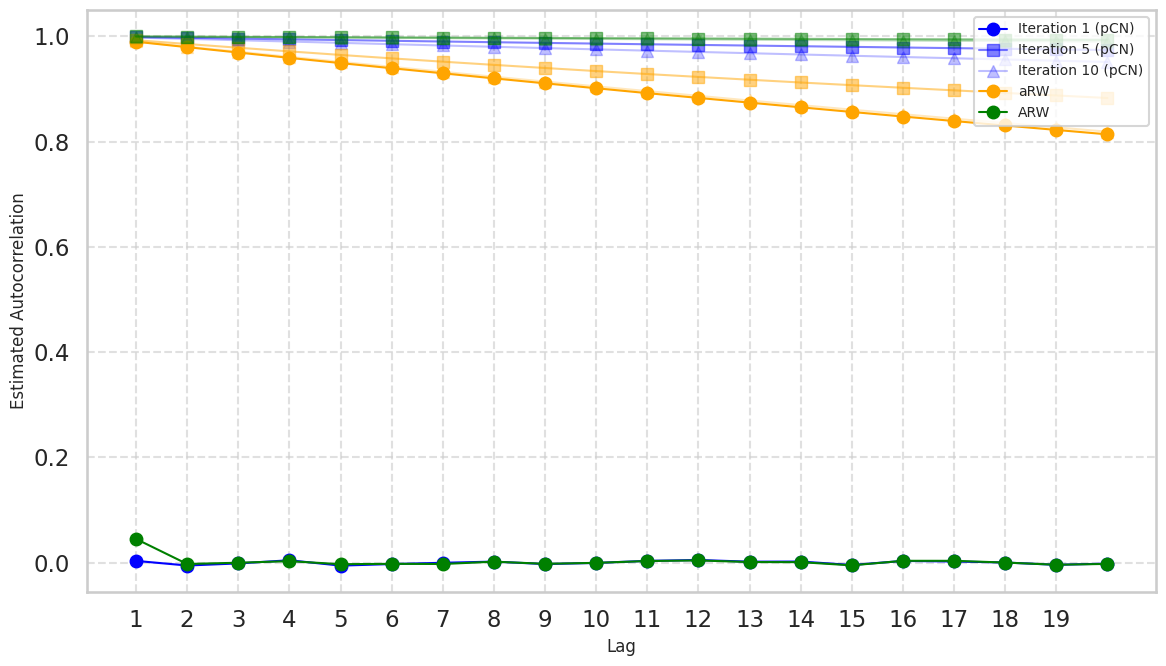

In [33]:
import matplotlib.pyplot as plt
import numpy as np

colors = ["blue", "orange", "green"]
alphas = [1., 0.5, 0.25]
component_idx = 2

plt.figure(figsize=(12, 7))

for p_idx, proposal in enumerate(idx_proposal):
    max_temp_idx = min(12, max([jnp.min(jnp.argwhere(PKLs[idx]['res'][6] == 1), axis=0)[1] for idx in idx_proposal[proposal]]))
    samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0, ..., component_idx, jnp.newaxis] for idx in idx_proposal[proposal]], axis=0)
    acfs = acf2(samples)[..., 0, 0]
    for idx_it, it in enumerate([1, 5, 10]):
        marker = ['o', 's', '^'][idx_it % 3]  # Use different markers for clarity
        plt.plot(np.arange(1, 21), acfs[:, it], 
                 marker=marker, 
                 label=f"Iteration {it} ({proposal})" if p_idx == 0 else f"{proposal}" if idx_it==0 else None,
                 color=colors[p_idx], 
                 alpha=alphas[idx_it],
                 linewidth=1.5)

# Beautify plot
plt.xlabel("Lag", fontsize=12)
plt.ylabel("Estimated Autocorrelation", fontsize=12)
#plt.title("Autocorrelation Function by Proposal and Iteration", fontsize=13)
plt.xticks(ticks=np.arange(1, 20, 1))  # Only integer x-ticks
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig(DIR + "ACF.pdf", dpi=300)
plt.show()


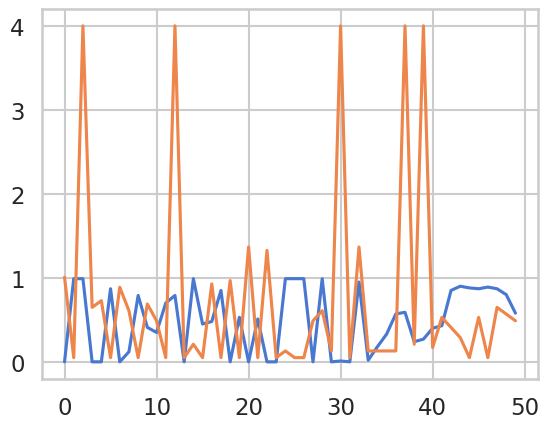

In [52]:
plt.plot(PKLs[2]['res'][3].reshape((50, 2)))

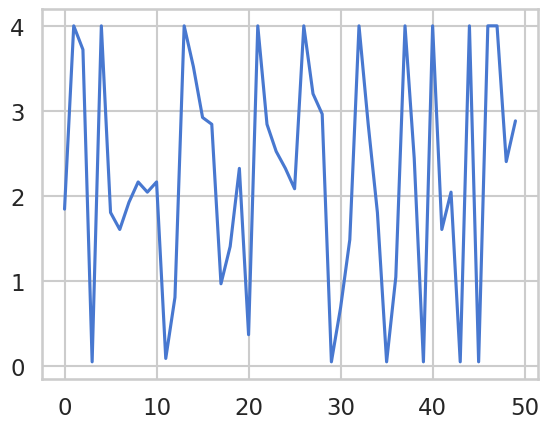

In [53]:
plt.plot(PKLs[1]['res'][3].reshape(-1))

In [5]:
for proposal in idx_proposal:
    for idx in idx_proposal[proposal]:
        if PKLs[idx]['res'][0] is None:
            print(idx)
            print(PKL_titles[idx])

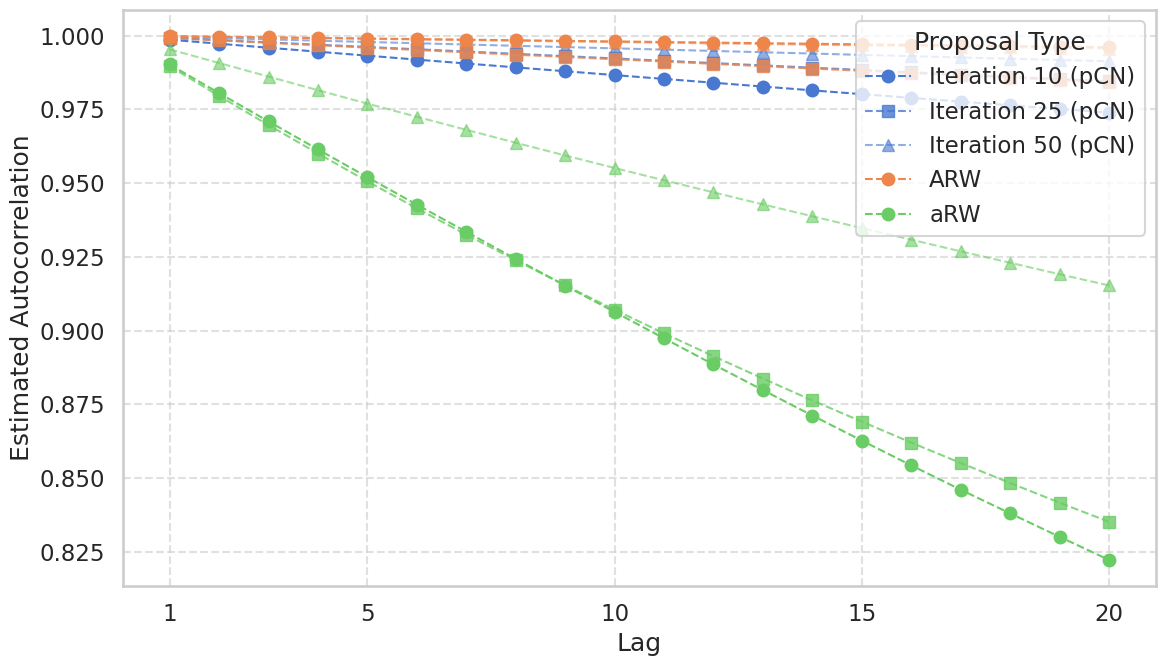

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

LAG = 20 # from 1 to 20 
xticks = np.arange(1, LAG+1)
display_x_ticks = np.concatenate([[1], np.arange(5, LAG+1, 5)])

# if there are too many dimension, we can restrict the samples to the marginal of the component of interest,
# and compute the acf for the marginal samplers
MARGINAL = True

# Match Seaborn style
sns.set(style='whitegrid', context='talk', palette='muted')

colors = sns.color_palette('muted')[:3]
alphas = [1., 0.8, 0.6]
component_idx = 5


plt.figure(figsize=(12, 7))

for p_idx, proposal in enumerate(idx_proposal):
    if MARGINAL:
        samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0, ..., component_idx, jnp.newaxis] for idx in idx_proposal[proposal]], axis=0) # tricks to avoid computing full acf since we are interested only in diagonal terms
        acfs = acf2(samples, max_order=LAG)[..., 0, 0]
    else:
        samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0] for idx in idx_proposal[proposal]], axis=0)
        acfs = acf2(samples, max_order=LAG)[..., component_idx, component_idx]
    for idx_it, it in enumerate([10, 25, 50]):
        marker = ['o', 's', '^'][idx_it % 3]
        label = f"Iteration {it} ({proposal})" if p_idx == 0 else f"{proposal}" if idx_it == 0 else None
        plt.plot(xticks, acfs[:, it], 
                 marker=marker, 
                 label=label,
                 color=colors[p_idx], 
                 alpha=alphas[idx_it],
                 linewidth=1.5,
                 linestyle="--")

# Beautify to match boxplot
plt.xlabel("Lag")
plt.ylabel("Estimated Autocorrelation")
plt.xticks(ticks=display_x_ticks)
plt.legend(title='Proposal Type', loc='upper right')

plt.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()
plt.savefig(DIR + "ACF.pdf", dpi=300)
plt.show()


(array([0.00727144, 0.00497518, 0.00663359, 0.00956765, 0.01632884,
        0.02321757, 0.03686735, 0.03138199, 0.04107724, 0.05396156,
        0.08470587, 0.08955322, 0.13024803, 0.16622251, 0.23536424,
        0.24327424, 0.29493972, 0.37824118, 0.42863212, 0.47851017,
        0.54625081, 0.64052339, 0.74168665, 0.73288326, 0.81809928,
        0.76911283, 0.78824936, 0.76171383, 0.67471185, 0.66769556,
        0.56194181, 0.52137405, 0.42531467, 0.33792999, 0.24837681,
        0.22311816, 0.18931223, 0.10218276, 0.0992486 , 0.05970229,
        0.02742732, 0.01607369, 0.01326717, 0.00892982, 0.0036995 ,
        0.00446491, 0.00395464, 0.00229624, 0.00433734, 0.00331679]),
 array([-3.69395256, -3.6155715 , -3.5371902 , -3.45880914, -3.38042784,
        -3.30204678, -3.22366571, -3.14528441, -3.06690335, -2.98852229,
        -2.91014099, -2.83175993, -2.75337863, -2.67499757, -2.59661651,
        -2.51823521, -2.43985415, -2.36147308, -2.28309178, -2.20471072,
        -2.12632942, -2.04

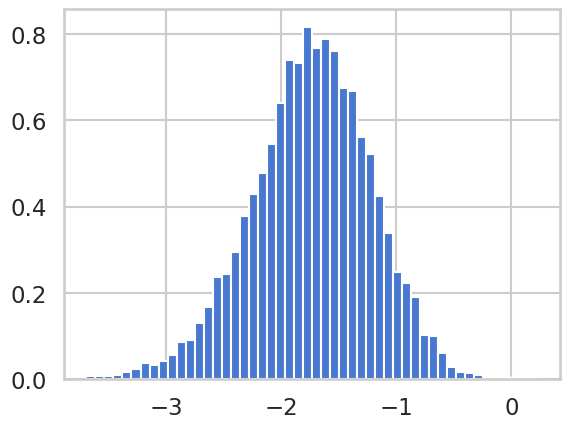

In [35]:
plt.hist(PKLs[1]['res'][0][0, -1, 0][..., 0].reshape(-1),bins=50, density=True)

In [56]:
idx_proposal

{'pCN': [0], 'aRW': [1]}

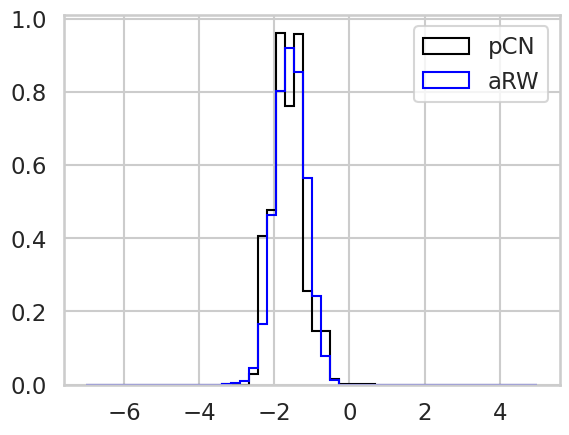

In [82]:
t=45
plt.hist(PKLs[0]['res'][0][0][t, 0, ..., 0].reshape(-1),bins=50,density=True,histtype='step',color='black', range=[-7, 5], label="pCN")
plt.hist(PKLs[1]['res'][0][0][t, 0, ..., 0].reshape(-1),bins=50,density=True,histtype='step',color='blue', range=[-7, 5], label="aRW")
plt.legend()